# 1. Recreate graphs

### a) Here we use subplots to get two axes in one figure
![Alt text](https://raw.githubusercontent.com/kokchun/assets/refs/heads/main/data_visualization/popular_games.png)

In [26]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

df = pd.read_csv("steam_top_100_played_games_list.csv")
df.shape


(100, 8)

In [27]:
df.columns

Index(['rank', 'name', 'thumbnail_url', 'store_link', 'price',
       'current_players', 'peak_today', 'genre_tags'],
      dtype='object')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   rank             100 non-null    int64 
 1   name             100 non-null    object
 2   thumbnail_url    100 non-null    object
 3   store_link       100 non-null    object
 4   price            100 non-null    object
 5   current_players  100 non-null    int64 
 6   peak_today       100 non-null    int64 
 7   genre_tags       100 non-null    object
dtypes: int64(3), object(5)
memory usage: 6.4+ KB


In [29]:
df["name"].head(10), df["price"].head(10)

(0       Counter-Strike 2
 1    PUBG: BATTLEGROUNDS
 2                 Dota 2
 3          Marvel Rivals
 4        Path of Exile 2
 5     Grand Theft Auto V
 6     NARAKA: BLADEPOINT
 7                   Rust
 8               Palworld
 9          Apex Legends™
 Name: name, dtype: object,
 0    Free To Play
 1    Free To Play
 2    Free To Play
 3    Free To Play
 4          £23.93
 5          £14.80
 6    Free To Play
 7          £34.99
 8          £24.99
 9    Free To Play
 Name: price, dtype: object)

In [30]:
df = df.head(10)
df

,rank,name,thumbnail_url,store_link,price,current_players,peak_today,genre_tags
0,1,Counter-Strike 2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/730/Counter...,Free To Play,1485535,1489929,"FPS, Shooter, Multiplayer, Competitive, Action..."
1,2,PUBG: BATTLEGROUNDS,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/578080/PUBG...,Free To Play,765150,765150,"Survival, Shooter, Battle Royale, Multiplayer,..."
2,3,Dota 2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/570/Dota_2?...,Free To Play,698757,715295,"Free to Play, MOBA, Multiplayer, Strategy, eSp..."
3,4,Marvel Rivals,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/2767030/Mar...,Free To Play,312427,565653,"Free to Play, Multiplayer, Hero Shooter, Third..."
4,5,Path of Exile 2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/2694490/Pat...,£23.93,258475,288757,"Action RPG, Hack and Slash, RPG, Action, Souls..."
5,6,Grand Theft Auto V,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/271590/Gran...,£14.80,207117,207117,"Open World, Action, Multiplayer, Crime, Mature"
6,7,NARAKA: BLADEPOINT,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/1203220/NAR...,Free To Play,201876,208643,"Battle Royale, Multiplayer, Martial Arts, PvP,..."
7,8,Rust,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/252490/Rust...,£34.99,168002,205358,"Survival, Crafting, Multiplayer, Open World, O..."
8,9,Palworld,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/1623730/Pal...,£24.99,165613,165613,"Open World, Survival, Creature Collector, Mult..."
9,10,Apex Legends™,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/1172470/Ape...,Free To Play,150754,151447,"Free to Play, Battle Royale, Multiplayer, FPS,..."


In [51]:
df_number_players_per_game = duckdb.query("""--sql
    SELECT
        name AS Game,
        SUM(current_players) AS "Number players"
    FROM
        df
    GROUP BY    
        Game
    ORDER BY 
        "Number players" DESC
""").df().set_index("Game")
df_number_players_per_game = df_number_players_per_game.head(10)
df_number_players_per_game

,Number players
Game,
Counter-Strike 2,1485535.0
PUBG: BATTLEGROUNDS,765150.0
Dota 2,698757.0
Marvel Rivals,312427.0
Path of Exile 2,258475.0
Grand Theft Auto V,207117.0
NARAKA: BLADEPOINT,201876.0
Rust,168002.0
Palworld,165613.0


In [32]:
df["price"].unique()

array(['Free To Play', '£23.93', '£14.80', '£34.99', '£24.99'],
      dtype=object)

In [39]:
df_price_per_game = duckdb.query("""--sql
    SELECT
        name AS Game,
        SUM(
            CASE
                WHEN price = 'Free To Play' THEN 0
                ELSE CAST(REPLACE(REPLACE(price, '£', ''), ' ', '') AS FLOAT)
            END
        ) AS "Price in pounds",
        SUM(current_players) AS "Number players"                         
    FROM
        df
    GROUP BY
        Game
    ORDER BY 
        "Number players" DESC
""").df().set_index("Game")
df_price_per_game = df_price_per_game.head(10).drop("Number players", axis= 1)
df_price_per_game

,Price in pounds
Game,
Counter-Strike 2,0.000000
PUBG: BATTLEGROUNDS,0.000000
Dota 2,0.000000
Marvel Rivals,0.000000
Path of Exile 2,23.930000
Grand Theft Auto V,14.800000
NARAKA: BLADEPOINT,0.000000
Rust,34.990002
Palworld,24.990000


In [196]:
games = df_price_per_game.index.tolist()
# games = ax1.containers

games

['Counter-Strike 2',
 'PUBG: BATTLEGROUNDS',
 'Dota 2',
 'Marvel Rivals',
 'Path of Exile 2',
 'Grand Theft Auto V',
 'NARAKA: BLADEPOINT',
 'Rust',
 'Palworld',
 'Apex Legends™']

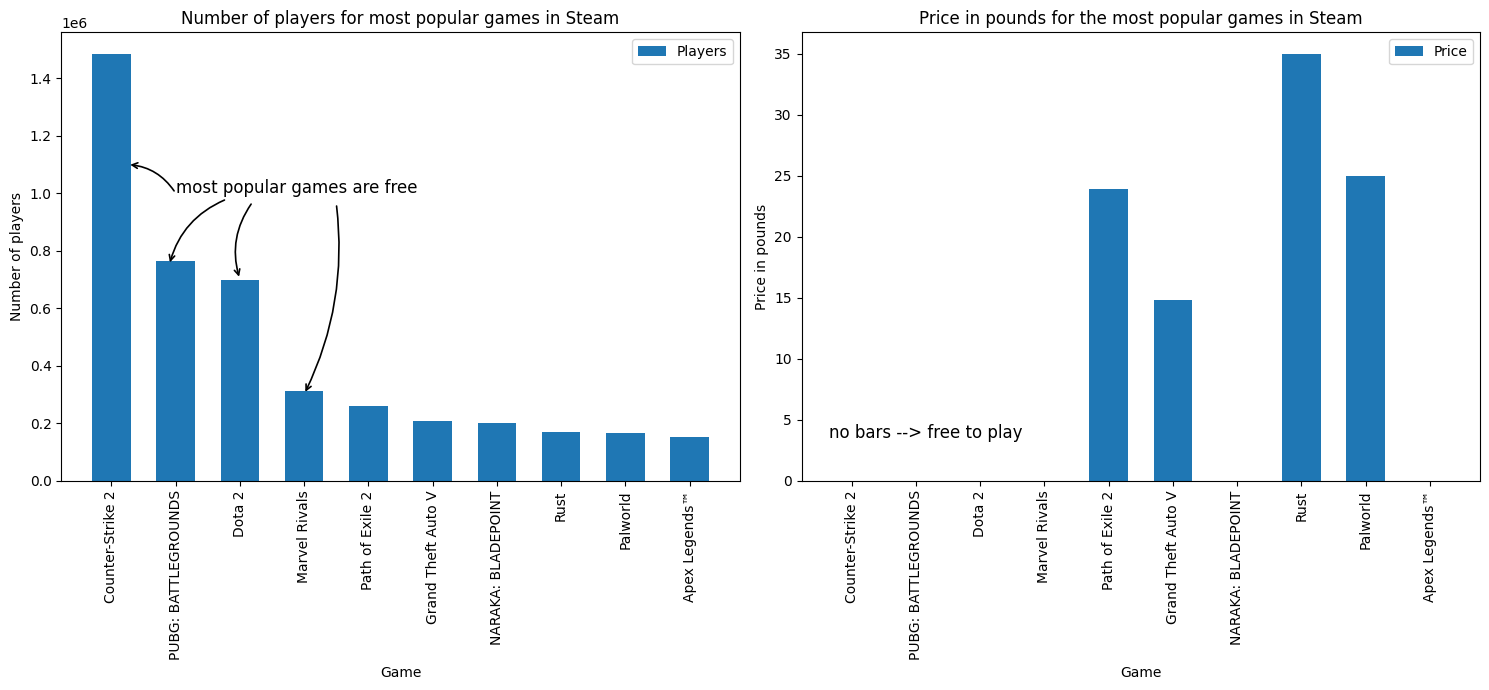

In [193]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))
ax1.bar(x=df_number_players_per_game.index, height=df_number_players_per_game["Number players"], 
        width= 0.6,
        label = "Players")
ax1.set(title = "Number of players for most popular games in Steam",
        xlabel= "Game",
        ylabel = "Number of players"
        )
ax1.tick_params(axis='x', rotation=90)
ax1.legend()
ax2.bar(x= df_price_per_game.index, height= df_price_per_game["Price in pounds"],
        label = "Price",
        width= 0.6)
ax2.set(title= "Price in pounds for the most popular games in Steam", 
        xlabel= "Game",
        ylabel= "Price in pounds"
        )
ax2.tick_params(axis='x', rotation=90)
ax2.legend()
arrowprops1= dict(arrowstyle = "->", linewidth = 1.2, connectionstyle = "arc3, rad=.25")
arrowprops2= dict(arrowstyle = "->", linewidth = 1.2, connectionstyle = "arc3, rad=-.15")

ax1.annotate(
    text="most popular games are free",
    xy=(1, 1000000),        
    fontsize=12
)
ax1.annotate(
    text="",             
    xy=(0.25, 1100000),       
    xytext=(1, 1000000), 
    arrowprops=arrowprops1
)
ax1.annotate(
    text="",               
    xy=(0.9, 750000),     
    xytext=(1.8, 980000),  
    arrowprops=arrowprops1
)
ax1.annotate(
    text="",               
    xy=(2, 700000),       
    xytext=(2.2, 970000),  
    arrowprops=arrowprops1
)
ax1.annotate(
    text="",               
    xy=(3, 300000),       
    xytext=(3.5, 965000),  
    arrowprops=arrowprops2
)
ax2.annotate(text= "no bars --> free to play",
             xy= (-.35,3.5),
             fontsize= 12)
fig.tight_layout()

### b) This one will require some data processing to be able to come to this point.

### Hint: df.explode() and df.join()

![Alt text](https://raw.githubusercontent.com/kokchun/assets/refs/heads/main/data_visualization/top5_genre_tags.png)



In [213]:
dfb = pd.read_csv("steam_top_100_played_games_list.csv")
dfb.head()

,rank,name,thumbnail_url,store_link,price,current_players,peak_today,genre_tags
0,1,Counter-Strike 2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/730/Counter...,Free To Play,1485535,1489929,"FPS, Shooter, Multiplayer, Competitive, Action..."
1,2,PUBG: BATTLEGROUNDS,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/578080/PUBG...,Free To Play,765150,765150,"Survival, Shooter, Battle Royale, Multiplayer,..."
2,3,Dota 2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/570/Dota_2?...,Free To Play,698757,715295,"Free to Play, MOBA, Multiplayer, Strategy, eSp..."
3,4,Marvel Rivals,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/2767030/Mar...,Free To Play,312427,565653,"Free to Play, Multiplayer, Hero Shooter, Third..."
4,5,Path of Exile 2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/2694490/Pat...,£23.93,258475,288757,"Action RPG, Hack and Slash, RPG, Action, Souls..."


In [212]:
genre= dfb.explode(["genre_tags"]).set_index("name")
genre

,rank,thumbnail_url,store_link,price,current_players,peak_today,genre_tags
name,,,,,,,
Counter-Strike 2,1,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/730/Counter...,Free To Play,1485535,1489929,"FPS, Shooter, Multiplayer, Competitive, Action..."
PUBG: BATTLEGROUNDS,2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/578080/PUBG...,Free To Play,765150,765150,"Survival, Shooter, Battle Royale, Multiplayer,..."
Dota 2,3,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/570/Dota_2?...,Free To Play,698757,715295,"Free to Play, MOBA, Multiplayer, Strategy, eSp..."
Marvel Rivals,4,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/2767030/Mar...,Free To Play,312427,565653,"Free to Play, Multiplayer, Hero Shooter, Third..."
Path of Exile 2,5,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/2694490/Pat...,£23.93,258475,288757,"Action RPG, Hack and Slash, RPG, Action, Souls..."
...,...,...,...,...,...,...,...
Sid Meier's Civilization® V,96,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/8930/Sid_Me...,£19.99,17916,21754,"Turn-Based Strategy, Strategy, Turn-Based, Mul..."
Counter-Strike,97,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/10/CounterS...,£7.19,17900,19275,"Action, FPS, Multiplayer, Shooter, Classic, Te..."
Cities: Skylines,98,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/255710/Citi...,£24.99,17866,18067,"City Builder, Simulation, Building, Management..."


In [214]:
dfb['genre_tags'] = dfb['genre_tags'].str.split(',').apply(lambda lst: [g.strip() for g in lst])
dfb['genre_tags']

0     [FPS, Shooter, Multiplayer, Competitive, Actio...
1     [Survival, Shooter, Battle Royale, Multiplayer...
2     [Free to Play, MOBA, Multiplayer, Strategy, eS...
3     [Free to Play, Multiplayer, Hero Shooter, Thir...
4     [Action RPG, Hack and Slash, RPG, Action, Soul...
                            ...                        
95    [Turn-Based Strategy, Strategy, Turn-Based, Mu...
96    [Action, FPS, Multiplayer, Shooter, Classic, T...
97    [City Builder, Simulation, Building, Managemen...
98    [Open World, Post-apocalyptic, Singleplayer, RPG]
99    [Free to Play, Survival, Zombies, Multiplayer,...
Name: genre_tags, Length: 100, dtype: object

In [215]:
df_exploded = dfb.explode('genre_tags')
# Nu heter kolumnen fortfarande genre_tags; byt gärna namn för tydlighet
df_exploded = df_exploded.rename(columns={'genre_tags': 'genre'})
df_exploded

,rank,name,thumbnail_url,store_link,price,current_players,peak_today,genre
0,1,Counter-Strike 2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/730/Counter...,Free To Play,1485535,1489929,FPS
0,1,Counter-Strike 2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/730/Counter...,Free To Play,1485535,1489929,Shooter
0,1,Counter-Strike 2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/730/Counter...,Free To Play,1485535,1489929,Multiplayer
0,1,Counter-Strike 2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/730/Counter...,Free To Play,1485535,1489929,Competitive
0,1,Counter-Strike 2,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/730/Counter...,Free To Play,1485535,1489929,Action
...,...,...,...,...,...,...,...,...
99,100,Unturned,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/304930/Untu...,Free To Play,16976,18080,Massively Multiplayer
99,100,Unturned,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/304930/Untu...,Free To Play,16976,18080,Indie
99,100,Unturned,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/304930/Untu...,Free To Play,16976,18080,Atmospheric
99,100,Unturned,https://shared.cloudflare.steamstatic.com//sto...,https://store.steampowered.com/app/304930/Untu...,Free To Play,16976,18080,Casual
